# Customer Retention Enhancement through Predictive Analysis

**Author:** Firdausi Jibrin
**Date:** 01 March, 2026
**Organization:** Lloyds Banking Group (Forage Project)

## Introduction
Customer churn occurs when customers stop doing business with a company, leading to potential revenue loss. Identifying and preventing churn is crucial for maintaining a stable customer base.

## Aim and Objectives
This project aims to:
- Analyze customer data
- Identify patterns associated with churn
- Prepare the dataset for predictive modeling.

# Task 1: Data Gathering and Exploratory Analysis

## Dataset Summary and Rationale
The dataset contains customer information, including demographic data, account details, and churn status.

**Key variables:**
- 'Customer ID': Unique identifier for each customer
- 'Age', 'Gender': Demographic features
- 'TransactionID', 'AmountSpent', 'ProductCategory': Financial Information
- 'ChurnStatus': Target variable indicating if the customer left (1) or stayed (0)

**Rationale for inclusion**
- These variables have been shown to influence customer behaviour and churn likelihood.
- Financial and account activity features help identify patterns that predict churn.
- Demographic variables allow segmentation and targeted retention strategies.

## Initial Data Inspection
Before cleaning, we inspect the dataset to understand distributions, identify missing values, and detect patterns.

In [84]:
df = None

In [85]:
import pandas as pd

In [86]:
file = "Customer_Churn_Data_Large.xlxs"

In [88]:
# Load dataset
dfs = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name=None)

In [89]:
# Load specific sheets
df_demo = dfs["Customer_Demographics"]
df_trans = dfs["Transaction_History"]
df_service = dfs["Customer_Service"]
df_online = dfs["Online_Activity"]
df_churn = dfs["Churn_Status"]

In [90]:
print(df_demo.columns)
print(df_trans.columns)
print(df_service.columns)
print(df_online.columns)
print(df_churn.columns)

Index(['CustomerID', 'Age', 'Gender', 'MaritalStatus', 'IncomeLevel'], dtype='object')
Index(['CustomerID', 'TransactionID', 'TransactionDate', 'AmountSpent',
       'ProductCategory'],
      dtype='object')
Index(['CustomerID', 'InteractionID', 'InteractionDate', 'InteractionType',
       'ResolutionStatus'],
      dtype='object')
Index(['CustomerID', 'LastLoginDate', 'LoginFrequency', 'ServiceUsage'], dtype='object')
Index(['CustomerID', 'ChurnStatus'], dtype='object')


In [91]:
# All datasets were merged using the CustomerID column to create a unified dataset
df = df_demo.merge(df_churn, on='CustomerID', how='left')
df = df.merge(df_trans, on='CustomerID', how='left')
df = df.merge(df_service, on='CustomerID', how='left')
df = df.merge(df_online, on='CustomerID', how='left')

In [92]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [93]:
# Check columns
df.columns

Index(['CustomerID', 'Age', 'Gender', 'MaritalStatus', 'IncomeLevel',
       'ChurnStatus', 'TransactionID', 'TransactionDate', 'AmountSpent',
       'ProductCategory', 'InteractionID', 'InteractionDate',
       'InteractionType', 'ResolutionStatus', 'LastLoginDate',
       'LoginFrequency', 'ServiceUsage'],
      dtype='object')

In [94]:
# View Dataset
df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,ChurnStatus,TransactionID,TransactionDate,AmountSpent,ProductCategory,InteractionID,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage
0,1,62,M,Single,Low,0,7194,2022-03-27,416.50,Electronics,6363.0,2022-03-31,Inquiry,Resolved,2023-10-21,34,Mobile App
1,2,65,M,Married,Low,1,7250,2022-08-08,54.96,Clothing,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website
2,2,65,M,Married,Low,1,9660,2022-07-25,197.50,Electronics,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website
3,2,65,M,Married,Low,1,2998,2022-01-25,101.31,Furniture,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website
4,2,65,M,Married,Low,1,1228,2022-07-24,397.37,Clothing,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website


In [95]:
# Dataset Overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6812 entries, 0 to 6811
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        6812 non-null   int64         
 1   Age               6812 non-null   int64         
 2   Gender            6812 non-null   object        
 3   MaritalStatus     6812 non-null   object        
 4   IncomeLevel       6812 non-null   object        
 5   ChurnStatus       6812 non-null   int64         
 6   TransactionID     6812 non-null   int64         
 7   TransactionDate   6812 non-null   datetime64[ns]
 8   AmountSpent       6812 non-null   float64       
 9   ProductCategory   6812 non-null   object        
 10  InteractionID     5204 non-null   float64       
 11  InteractionDate   5204 non-null   datetime64[ns]
 12  InteractionType   5204 non-null   object        
 13  ResolutionStatus  5204 non-null   object        
 14  LastLoginDate     6812 n

In [96]:
# Summary Statistics
df.describe()

,CustomerID,Age,ChurnStatus,TransactionID,TransactionDate,AmountSpent,InteractionID,InteractionDate,LastLoginDate,LoginFrequency
count,6812.000000,6812.000000,6812.000000,6812.000000,6812,6812.000000,5204.000000,5204,6812,6812.000000
mean,500.169260,43.274516,0.198473,5497.323253,2022-07-01 02:11:29.136817408,251.620527,5921.861261,2022-07-01 16:31:10.561106944,2023-07-06 04:56:47.633587712,25.724310
min,1.000000,18.000000,0.000000,1000.000000,2022-01-01 00:00:00,5.180000,2015.000000,2022-01-01 00:00:00,2023-01-01 00:00:00,1.000000
25%,247.000000,30.000000,0.000000,3223.500000,2022-04-02 00:00:00,127.100000,3873.250000,2022-04-07 00:00:00,2023-04-12 00:00:00,14.000000
50%,505.500000,44.000000,0.000000,5515.000000,2022-07-01 00:00:00,251.845000,5903.000000,2022-07-02 00:00:00,2023-07-13 00:00:00,26.000000
75%,750.000000,56.000000,0.000000,7675.250000,2022-09-30 00:00:00,375.280000,7851.000000,2022-09-25 00:00:00,2023-10-01 00:00:00,38.000000
max,1000.000000,69.000000,1.000000,9997.000000,2022-12-31 00:00:00,499.860000,9997.000000,2022-12-30 00:00:00,2023-12-31 00:00:00,49.000000
std,286.704642,15.286788,0.398880,2584.768541,NaN,142.901693,2332.331260,NaN,NaN,14.062032


In [71]:
# Missing values and duplicates
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis
EDA was conducted to understand the dataset and identify patterns related to customer churn.

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

## Demographics Visualizations

Text(0.5, 1.0, 'Churn Distribution')

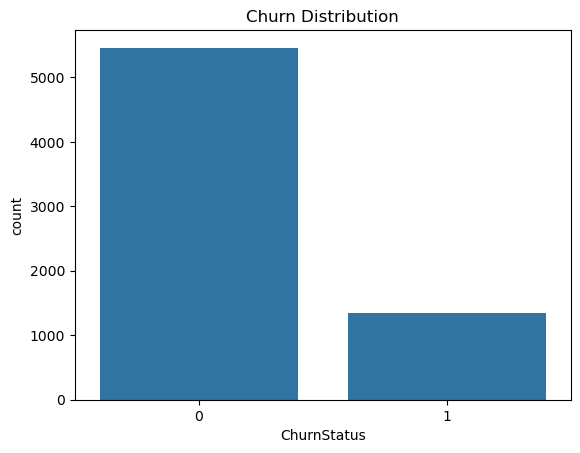

In [73]:
# Churn Distribution
sns.countplot(x='ChurnStatus', data=df)
plt.title('Churn Distribution')

Text(0.5, 1.0, 'Age Distribution')

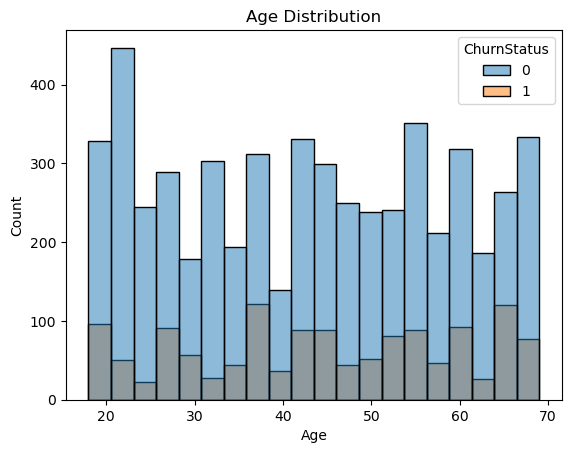

In [74]:
# Age Distribution
sns.histplot(data=df, x='Age', hue='ChurnStatus', bins=20)
plt.title('Age Distribution')

Text(0.5, 1.0, 'Gender Distribution')

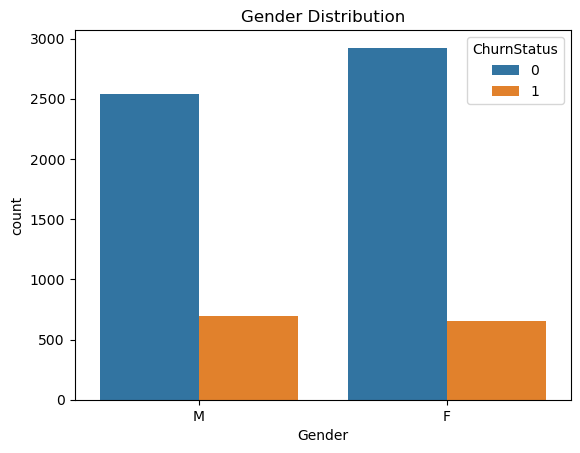

In [75]:
# Gender Distribution
sns.countplot(x='Gender', hue='ChurnStatus', data=df)
plt.title("Gender Distribution")

Text(0.5, 1.0, 'Income Level Distribution')

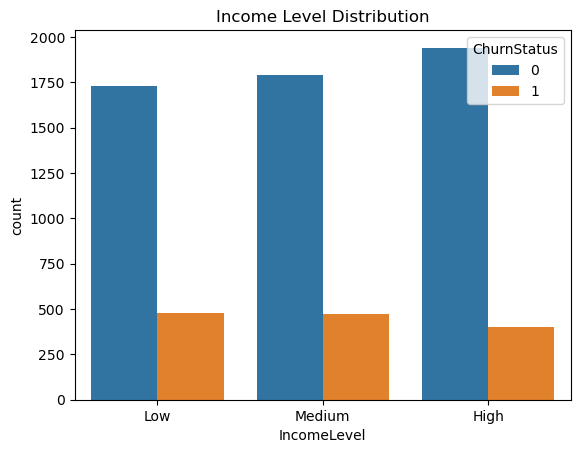

In [76]:
# Income Level Distribution
sns.countplot(x='IncomeLevel', hue='ChurnStatus', data=df)
plt.title("Income Level Distribution")

## Transaction Visualizations

Text(0.5, 1.0, 'Transaction History')

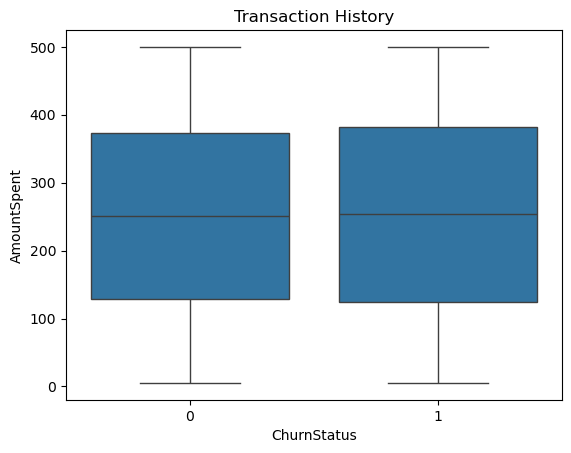

In [77]:
# Transactions vs Churn
sns.boxplot(x='ChurnStatus', y='AmountSpent', data=df)
plt.title("Transaction History")

## Customer Service Visualizations

Text(0.5, 1.0, 'Resolution vs Churn')

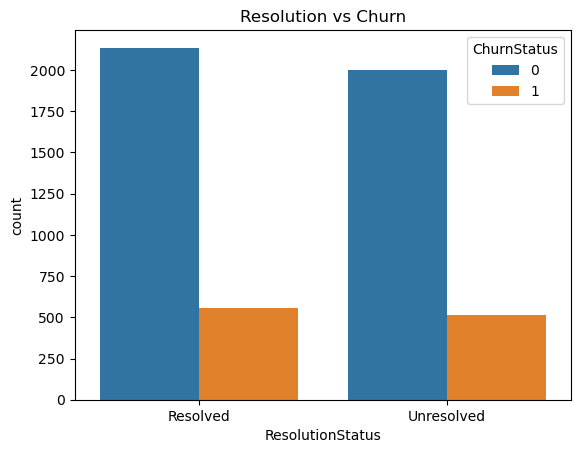

In [78]:
# Resolution Status
sns.countplot(x='ResolutionStatus', hue='ChurnStatus', data=df)
plt.title("Resolution vs Churn")

## Online Activity Visualizations

Text(0.5, 1.0, 'Login Distribution')

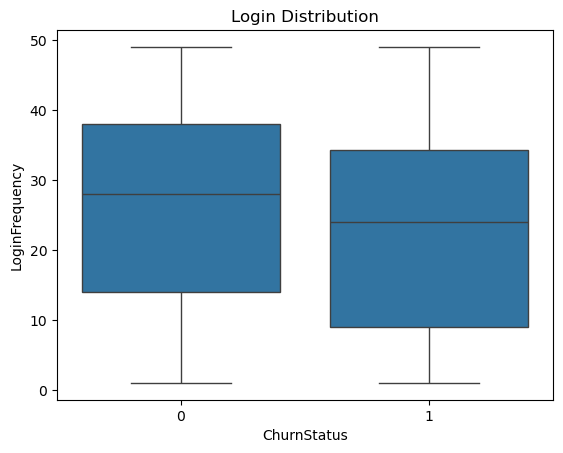

In [79]:
# Login Distribution
sns.boxplot(x='ChurnStatus', y='LoginFrequency', data=df)
plt.title("Login Distribution")

Text(0.5, 1.0, 'Service Usage Distribution')

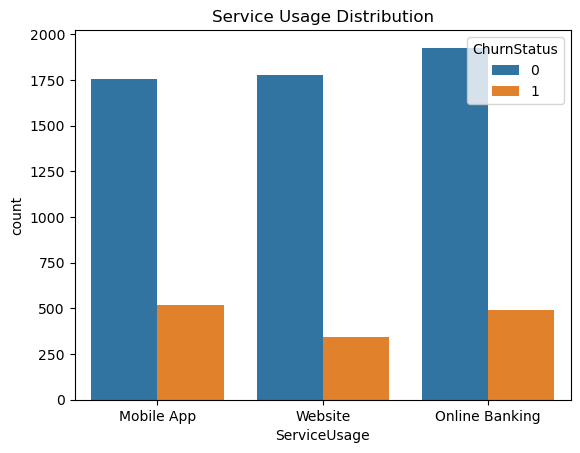

In [80]:
# Service Usage Distribution
sns.countplot(hue='ChurnStatus', x='ServiceUsage', data=df)
plt.title("Service Usage Distribution")

## Correlation Heatmap
This helps identify which features relate to churn.

Text(0.5, 1.0, 'Correlation Heatmap')

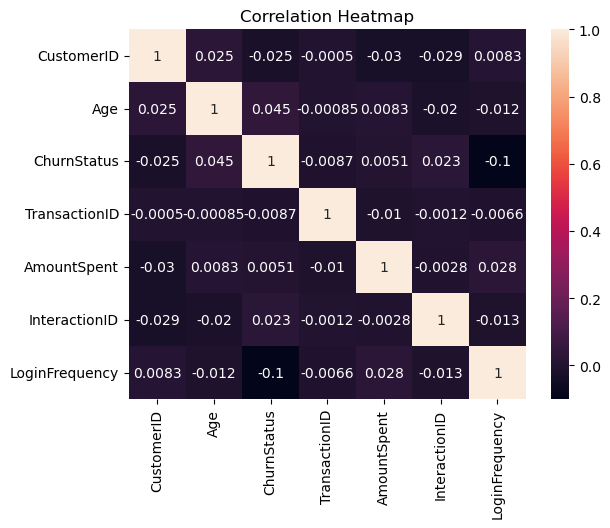

In [81]:
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")

## Key Findings
- According to the Churn Distribution Visualization, the number of customers who stayed is significantly higher than the number of customers who churned or left
- The Age Distribution visualization also shows the number of customers who stayed encompasses those who age. customers who churned where within the range of 100 in number compared to those who staywed.
- The Gender Distribution visualization showed the female gender of those who stayed were significantly higher than the male gender.
- In relation to Income Level of customers, those with higher income level were greater than medium income level, and medium income earners were slightly higher than low income earners. High income earners stayed most.
- In view of the amount spent by customers, customers who left spent slightly higher than those who stayed.
- According to the resolution status of the data, the number of resolved cases for those who stayed was slightly higher than those who left. The visualization shows those who churned having more unresolved cases than those who stayed.
- The Login distribution shows those who stayed had more login distribution than those who churned.
- The service usage distribution showed customers who used online banking where more in numbers than customers who used website or mobile app. Customers who churned mostly made use of the website service.

## Data Cleaning and Preprocessing
The following preprocessing steps were performed:

In [82]:
# Duplicate Removal
df = df.drop_duplicates(inplace=True)

In [97]:
# Encoding
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ['CustomerID', 'ChurnStatus']]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [98]:
# Scale numeric columns
from sklearn.preprocessing import StandardScaler
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [99]:
df.to_excel("Cleaned_Churned_Dataset.xlsx", index=False)